# 🩺 Breast Cancer Classification with Machine Learning

## Introduction
Breast cancer is one of the most common cancers worldwide, and early detection is critical for effective treatment.  
The **Breast Cancer Wisconsin dataset** is a well‑known benchmark dataset that contains features computed from digitized images of fine needle aspirates of breast masses. Each sample is described by 30 numerical features that capture cell characteristics such as radius, texture, smoothness, and concavity.  

The dataset is labeled into two categories:
- **Malignant (cancerous)**
- **Benign (non‑cancerous)**

## Goal
The primary goal of this project is to build and evaluate machine learning models that can **classify tumors as malignant or benign** based on these features.  
By comparing different models and preprocessing techniques (Scaled vs PCA), we aim to identify the most reliable approach for maximizing recall — ensuring malignant cases are detected — while maintaining strong overall performance.


### importing libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder

## Reading the data 

In [2]:
data = pd.read_csv("data.csv")

## EDA

In [3]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
## Handling missing values (Unamed : 23)
data.drop("Unnamed: 32",axis = 1 , inplace = True)

In [8]:
data.isna().sum().tail()

compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [9]:
## Drop unnecessary columns (ID not needed)
data.drop("id",axis = 1 , inplace = True)

## Visualization

Text(0.5, 1.0, 'Distribution of Diagnosis (Malignant vs Benign)')

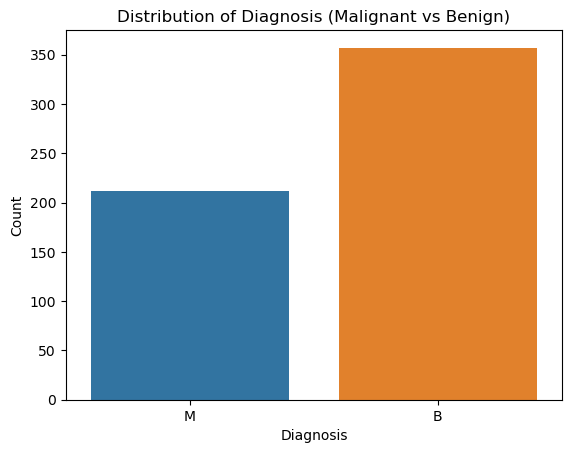

In [10]:
sns.countplot(x ="diagnosis",hue = 'diagnosis',data = data )
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.title("Distribution of Diagnosis (Malignant vs Benign)")

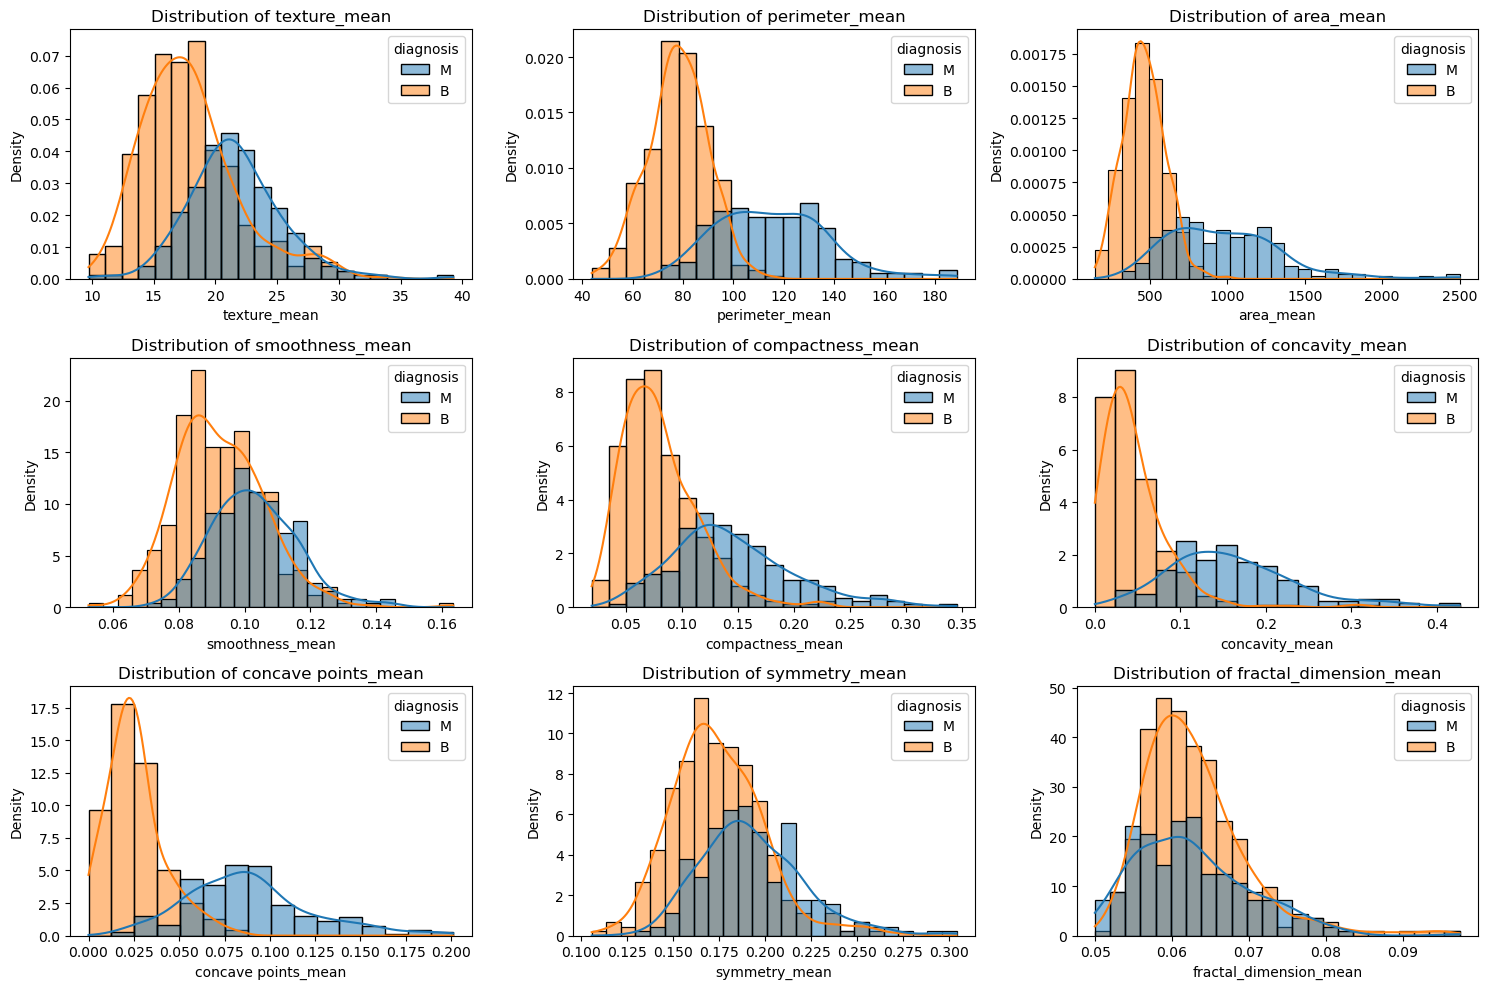

In [11]:
m_col = [
    'texture_mean','perimeter_mean','area_mean','smoothness_mean',
    'compactness_mean','concavity_mean','concave points_mean',
    'symmetry_mean','fractal_dimension_mean'
]

# Create a 3x3 grid for 9 features
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.ravel()  # flatten to 1D array

# Loop through features
for idx, col in enumerate(m_col):
    sns.histplot(data=data, x=col, kde=True, ax=axes[idx],stat= 'density', hue="diagnosis")
    axes[idx].set_title(f"Distribution of {col}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Density")

plt.tight_layout()
plt.show()


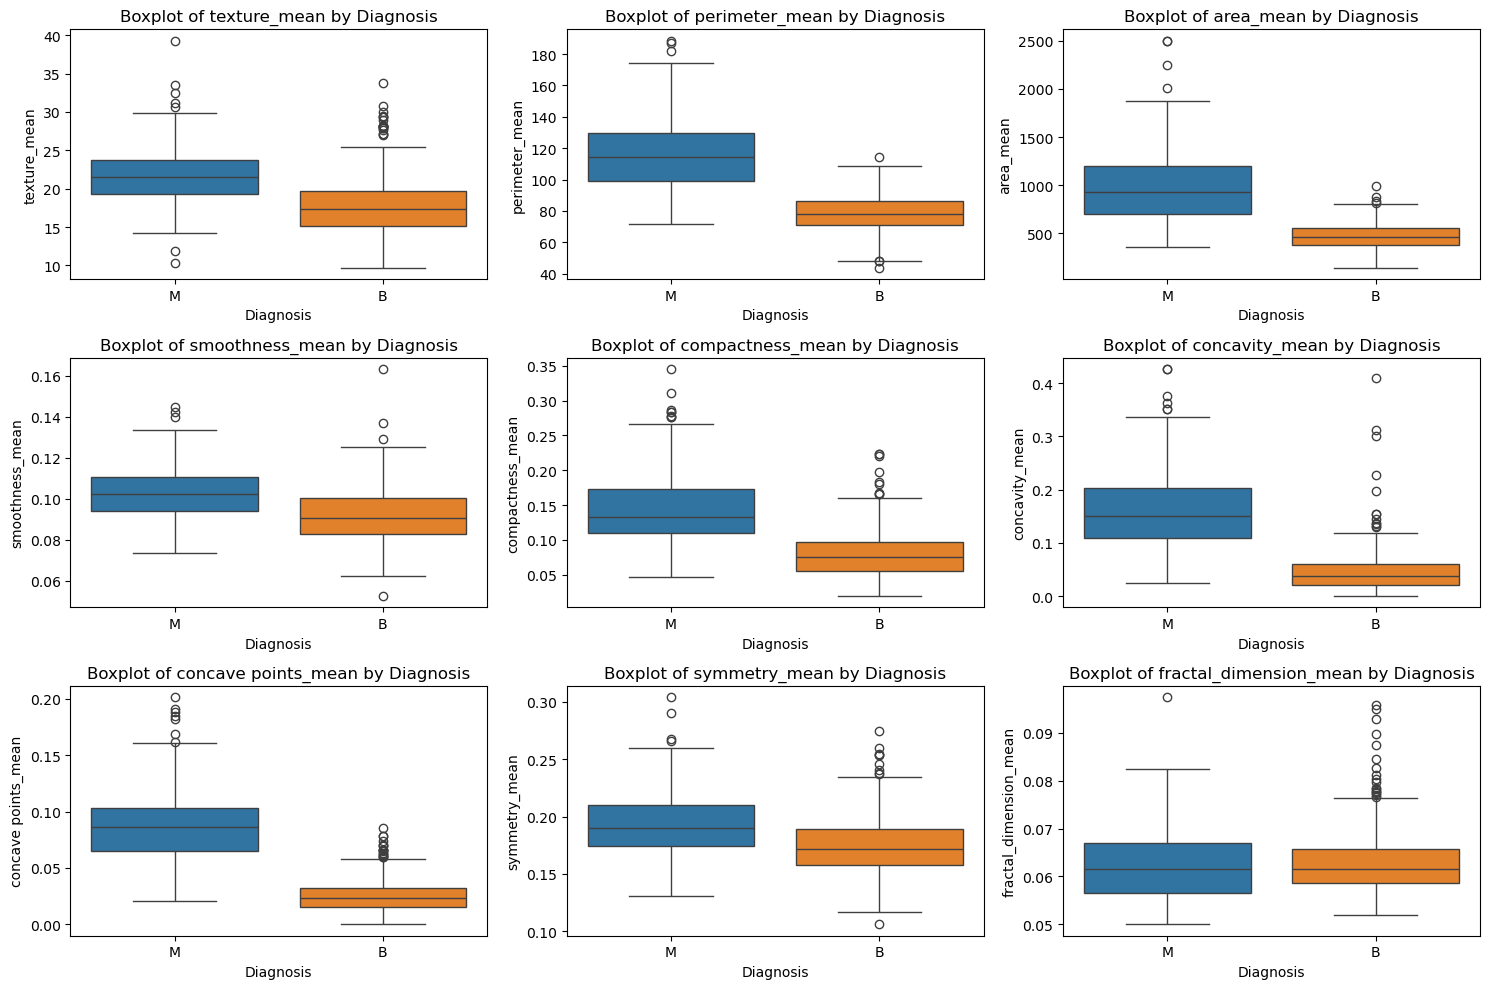

In [49]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(m_col):
    sns.boxplot(data=data, x="diagnosis", y=col, ax=axes[idx],hue= 'diagnosis' )
    axes[idx].set_title(f"Boxplot of {col} by Diagnosis")
    axes[idx].set_xlabel("Diagnosis")
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

## Preprocessing 

In [14]:
le = LabelEncoder()
data['diagnosis_encoded'] = le.fit_transform(data['diagnosis'])
data_encoded = data.drop('diagnosis',axis = 1)
data_encoded.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_encoded
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [15]:
# vis heat map for data >0.75 

corr = data_encoded.corr()
threshold = 0.75
# Filter features with correlation > threshold with the target
thre_filter = corr["diagnosis_encoded"].abs() > threshold
corr_features = corr.index[thre_filter].tolist()

print("Highly correlated features with diagnosis:", corr_features)


Highly correlated features with diagnosis: ['concave points_mean', 'radius_worst', 'perimeter_worst', 'concave points_worst', 'diagnosis_encoded']


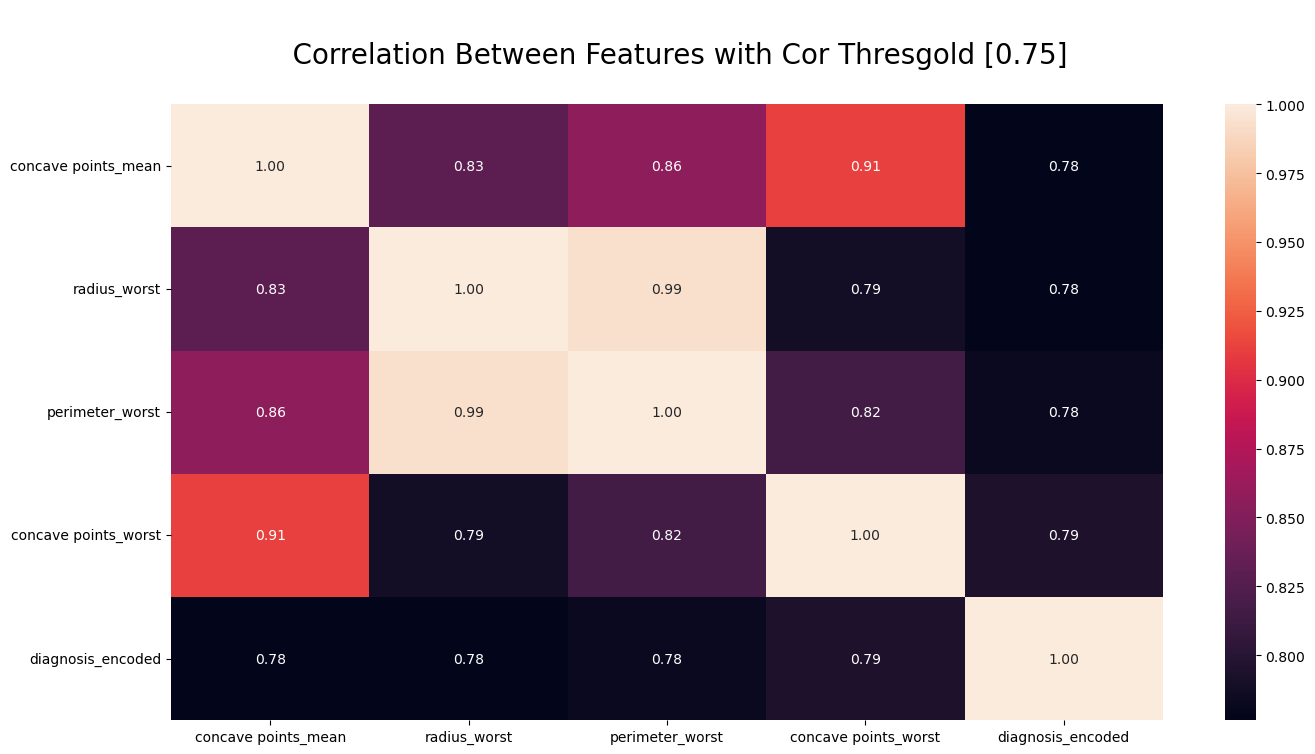

In [16]:
plt.figure(figsize=[16,8])
sns.heatmap(data_encoded[corr_features].corr(), annot = True, fmt = ".2f")
plt.title("\n   Correlation Between Features with Cor Thresgold [0.75]\n",fontsize=20)
plt.show()

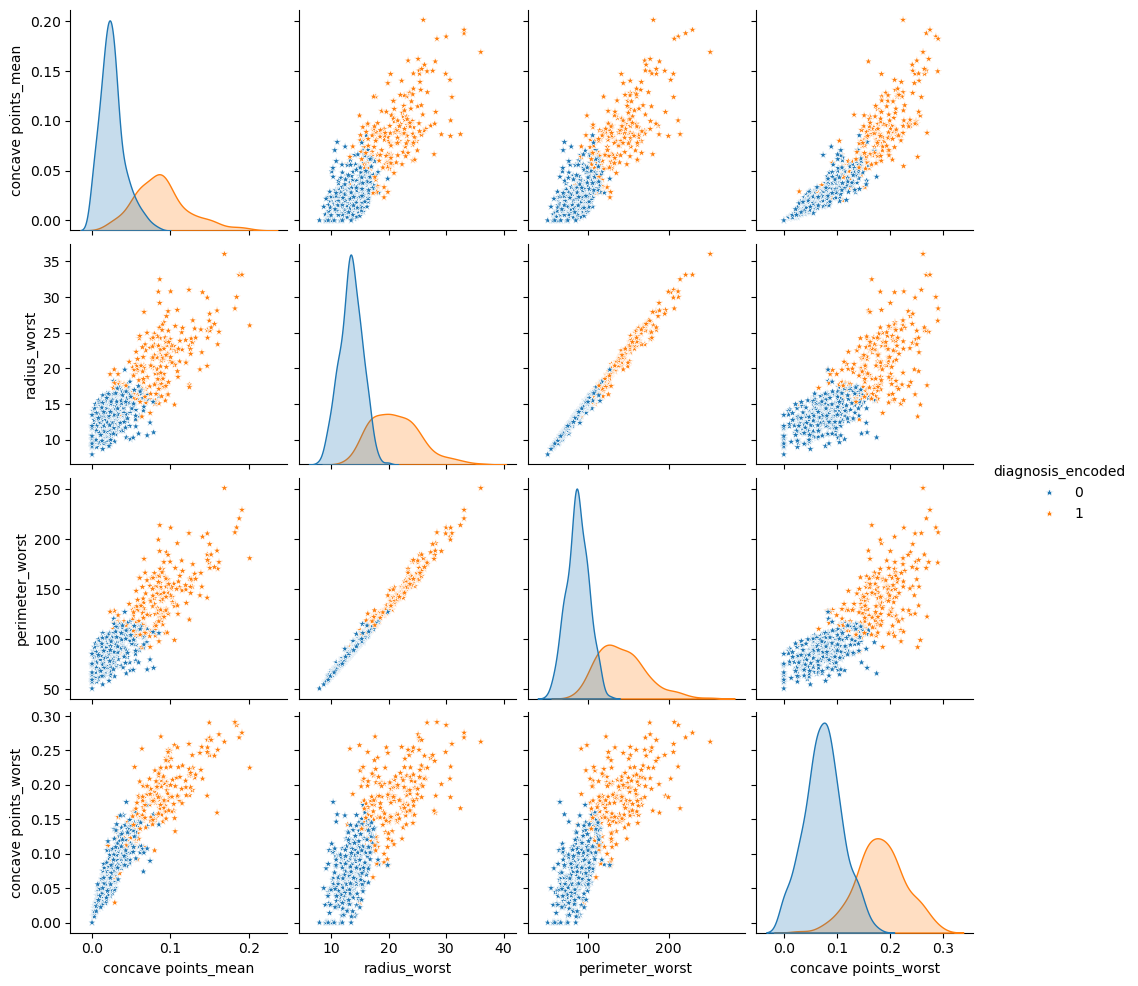

In [17]:
sns.pairplot(data_encoded[corr_features], diag_kind = "kde" , markers = "*", hue="diagnosis_encoded") #1 for M 0 for B
plt.show()

In [18]:
#scaling the data
X = data_encoded.drop(columns = ["diagnosis_encoded"])
y = data_encoded["diagnosis_encoded"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


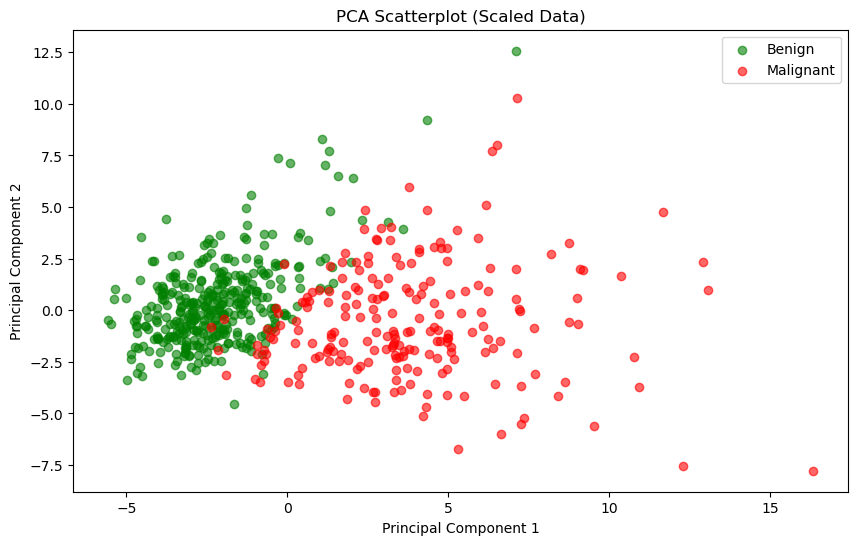

In [22]:
### i think we should scaling the data 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Scatterplot
plt.figure(figsize=(10,6))
plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1], c="green", label="Benign", alpha=0.6)
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1], c="red", label="Malignant", alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatterplot (Scaled Data)")
plt.legend()
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [24]:
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca,y,test_size=0.2,random_state=42)

## Modeling 

In [25]:
def evaluate_models(models, X_train, X_test, X_train_pca, X_test_pca, y_train, y_test):
    results = []
    for name, model in models.items():
        # Scaled data
        model.fit(X_train, y_train)
        y_pred_scaled = model.predict(X_test)
        results.append([name, "Scaled",
                        accuracy_score(y_test, y_pred_scaled),
                        precision_score(y_test, y_pred_scaled),
                        recall_score(y_test, y_pred_scaled),
                        f1_score(y_test, y_pred_scaled),
                        roc_auc_score(y_test, y_pred_scaled)])
        
        # PCA data
        model.fit(X_train_pca, y_train)
        y_pred_pca = model.predict(X_test_pca)
        results.append([name, "PCA",
                        accuracy_score(y_test, y_pred_pca),
                        precision_score(y_test, y_pred_pca),
                        recall_score(y_test, y_pred_pca),
                        f1_score(y_test, y_pred_pca),
                        roc_auc_score(y_test, y_pred_pca)])
    
    # Convert to DataFrame for neat display
    df_results = pd.DataFrame(results, columns=["Model","Data","Accuracy","Precision","Recall","F1","ROC-AUC"])
    return df_results


In [30]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
}
results_df = evaluate_models(models, X_train, X_test, X_train_pca, X_test_pca, y_train, y_test)
results_df


,Model,Data,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Scaled,0.973684,0.976190,0.953488,0.964706,0.969702
1,Logistic Regression,PCA,0.991228,1.000000,0.976744,0.988235,0.988372
2,Random Forest,Scaled,0.964912,0.975610,0.930233,0.952381,0.958074
3,Random Forest,PCA,0.973684,0.976190,0.953488,0.964706,0.969702
4,XGBoost,Scaled,0.956140,0.952381,0.930233,0.941176,0.951032
5,XGBoost,PCA,0.964912,0.953488,0.953488,0.953488,0.962660
6,SVM,Scaled,0.973684,0.976190,0.953488,0.964706,0.969702
7,SVM,PCA,0.964912,1.000000,0.906977,0.951220,0.953488
8,KNN,Scaled,0.947368,0.930233,0.930233,0.930233,0.943990
9,KNN,PCA,0.973684,0.954545,0.976744,0.965517,0.974288


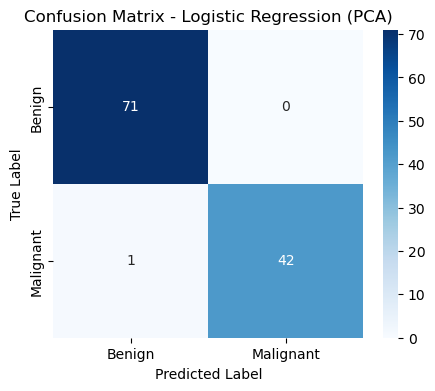

              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99        71
   Malignant       1.00      0.98      0.99        43

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



In [34]:
model = LogisticRegression()
model.fit(X_train_pca,y_train)
y_pred_pca = model.predict(X_test_pca)
cm = confusion_matrix(y_test,y_pred_pca)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])
plt.title("Confusion Matrix - Logistic Regression (PCA)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_pca, target_names=["Benign", "Malignant"]))

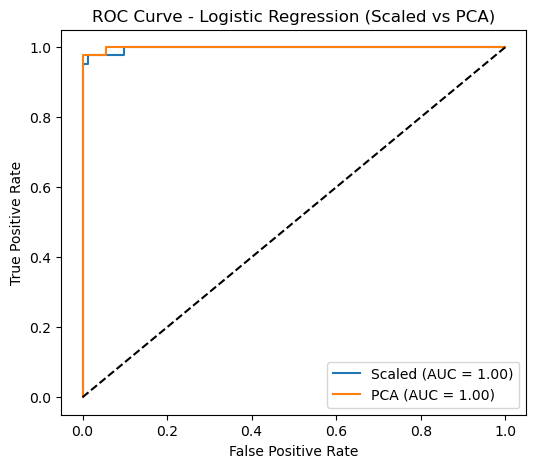

In [36]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Fit model on scaled data
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred_proba_scaled = model.predict_proba(X_test)[:,1]

# Fit model on PCA data
model.fit(X_train_pca, y_train)
y_pred_proba_pca = model.predict_proba(X_test_pca)[:,1]

# ROC curve for scaled
fpr_scaled, tpr_scaled, _ = roc_curve(y_test, y_pred_proba_scaled)
roc_auc_scaled = auc(fpr_scaled, tpr_scaled)

# ROC curve for PCA
fpr_pca, tpr_pca, _ = roc_curve(y_test, y_pred_proba_pca)
roc_auc_pca = auc(fpr_pca, tpr_pca)

# Plot both curves
plt.figure(figsize=(6,5))
plt.plot(fpr_scaled, tpr_scaled, label=f'Scaled (AUC = {roc_auc_scaled:.2f})')
plt.plot(fpr_pca, tpr_pca, label=f'PCA (AUC = {roc_auc_pca:.2f})')
plt.plot([0,1],[0,1],'k--')  # diagonal line
plt.title("ROC Curve - Logistic Regression (Scaled vs PCA)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


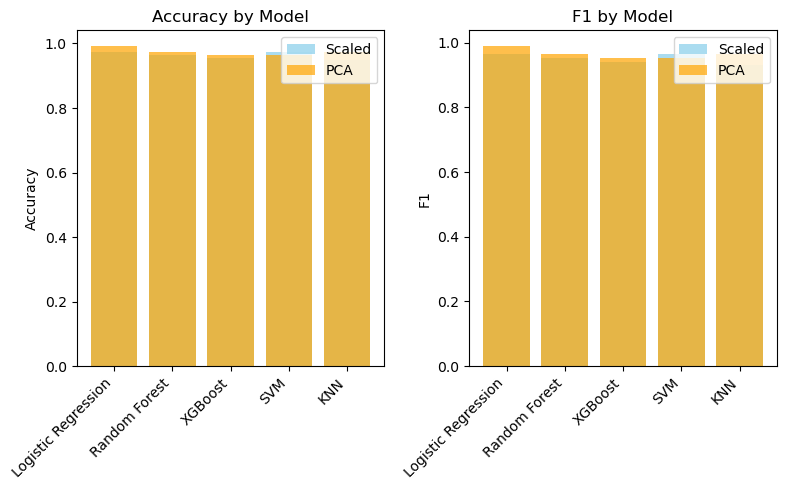

In [37]:
import matplotlib.pyplot as plt

# Accuracy bar chart
plt.figure(figsize=(8,5))
for i, metric in enumerate(["Accuracy", "F1"]):
    plt.subplot(1,2,i+1)  # two plots side by side
    for data_type, color in zip(["Scaled","PCA"], ["skyblue","orange"]):
        subset = results_df[results_df["Data"]==data_type]
        plt.bar(subset["Model"], subset[metric], label=data_type, alpha=0.7, color=color)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric} by Model")
    plt.legend()

plt.tight_layout()
plt.show()


# 🏁 Final Conclusion

Logistic Regression with PCA achieved excellent performance across Accuracy, F1, and ROC‑AUC.  
The confusion matrix shows **one malignant case misclassified as benign (false negative)**, which reduces recall slightly.  

In medical contexts, recall is the most critical metric:  
- **False negatives** are dangerous, as they risk missing cancer cases.  
- **False positives** are less harmful, leading only to extra testing.  

Despite this single error, recall remains very high, and overall performance is strong.  
This demonstrates that Logistic Regression with PCA is a reliable choice, though threshold tuning could be considered to further minimize false negatives.  

**Key Takeaway:**  
👉 Logistic Regression with PCA is a strong model, achieving high accuracy and sensitivity, with only one malignant case missed.
